# 2D Advection-Diffusion + BRNS Reactions via Operator Splitting

This notebook couples a simple 2D transport solver on a $20\times20$ grid with a model-dependent BRNS reaction library.

Workflow per time step:
1. Explicit advection-diffusion step for all species,
2. Cell-wise reaction update via the shared library,
3. Visualization of initial and final state.

Before running, build the library with [build_brns_reaction_lib.sh](../build_brns_reaction_lib.sh), e.g. for [models/multiple_species_example.yaml](../models/multiple_species_example.yaml).


In [14]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
if not (repo_root / 'acg_brns').exists() and (repo_root.parent / 'acg_brns').exists():
    repo_root = repo_root.parent

module_path = repo_root / 'notebooks' / 'utils' / 'brns_reaction_library.py'
if not module_path.exists():
    raise FileNotFoundError(f'Expected wrapper module at: {module_path}')

spec = importlib.util.spec_from_file_location('brns_reaction_library', module_path)
if spec is None or spec.loader is None:
    raise ImportError(f'Cannot load module spec from: {module_path}')
_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_module)

BRNSReactionLibrary = _module.BRNSReactionLibrary

In [15]:
model_name = 'multiple_species_example'
build_dir = repo_root / 'build' / model_name
library = BRNSReactionLibrary.from_build_dir(build_dir)

print(f'Library: {library.library_path}')
print(f'n_species   = {library.n_species}')
print(f'n_reactions = {library.n_reactions}')
print(f'n_parameters= {library.n_parameters}')
print('species_names =', library.species_names or '<not provided>')
print('parameter_defaults =', library.default_parameter_values)

Library: /mnt/c/Tecklenburg.J/work/thermooptiplan/BRNSPackage/build/multiple_species_example_/lib/libbrns_reactions_multiple_species_example_.so
n_species   = 5
n_reactions = 3
n_parameters= 3
species_names = ['diss_a', 'diss_b', 'diss_c', 'diss_d', 'diss_e']
parameter_defaults = [0.001 0.001 0.001]


In [10]:
nx = ny = 20
lx = ly = 1.0
dx = lx / (nx - 1)
dy = ly / (ny - 1)
dt = 50
n_steps = 100

vx = 0.0000
vy = 0.0000
diffusivities = np.linspace(1.0e-4, 3.0e-4, library.n_species)
porosity = 0.35
water_saturation = 1.0
parameter_vector = library.default_parameter_values.copy()

x = np.linspace(0.0, lx, nx)
y = np.linspace(0.0, ly, ny)
X, Y = np.meshgrid(x, y)
positions = np.column_stack([X.ravel(), Y.ravel(), np.zeros(nx * ny)])

In [11]:
def make_initial_conditions(n_species: int, X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    fields = np.zeros((n_species, *X.shape), dtype=np.float64)

    if n_species >= 1:
        fields[0] = np.exp(-((X - 0.18) ** 2 + (Y - 0.50) ** 2) / 0.010)
    if n_species >= 2:
        fields[1] = 0.8 * np.exp(-((X - 0.55) ** 2 + (Y - 0.20) ** 2) / 0.020)
    if n_species >= 3:
        fields[2] = 0.15 * np.exp(-((X - 0.50) ** 2 + (Y - 0.75) ** 2) / 0.030)
    if n_species >= 4:
        fields[3] = 0.10 * (X < 0.15).astype(float)
    if n_species >= 5:
        fields[4] = 0.05 * (Y > 0.85).astype(float)
    for species in range(5, n_species):
        cx = 0.2 + 0.6 * ((species - 5) % 3) / 2.0
        cy = 0.2 + 0.6 * ((species - 5) // 3 % 3) / 2.0
        fields[species] = 0.05 * np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / 0.025)

    return fields


def apply_neumann_boundaries(field: np.ndarray) -> np.ndarray:
    field[:, 0] = field[:, 1]
    field[:, -1] = field[:, -2]
    field[0, :] = field[1, :]
    field[-1, :] = field[-2, :]
    return field


def transport_step(fields: np.ndarray, diffusivities: np.ndarray, dt: float, dx: float, dy: float, vx: float, vy: float) -> np.ndarray:
    updated = fields.copy()
    for s in range(fields.shape[0]):
        u = fields[s]
        laplacian = (
            (np.roll(u, -1, axis=1) - 2.0 * u + np.roll(u, 1, axis=1)) / dx**2
            + (np.roll(u, -1, axis=0) - 2.0 * u + np.roll(u, 1, axis=0)) / dy**2
        )
        dudx = (u - np.roll(u, 1, axis=1)) / dx
        dudy = (u - np.roll(u, 1, axis=0)) / dy
        updated[s] = u + dt * (diffusivities[s] * laplacian - vx * dudx - vy * dudy)
        updated[s] = apply_neumann_boundaries(updated[s])
        updated[s] = np.clip(updated[s], 1.0e-12, None)
    return updated


def reaction_step(fields_before_transport: np.ndarray, fields_after_transport: np.ndarray) -> np.ndarray:
    transported = fields_after_transport.reshape(library.n_species, -1).T
    previous = fields_before_transport.reshape(library.n_species, -1).T
    reacted = library.react_batch(
        transported,
        previous_state=previous,
        dt=dt,
        positions=positions,
        porosity=porosity,
        water_saturation=water_saturation,
        parameter_vector=parameter_vector,
        max_substeps_per_cell=1,
        on_cell_failure='keep_transport',
        verbose_failures=False,
    )
    return reacted.T.reshape(library.n_species, ny, nx)


def plot_species(fields: np.ndarray, title: str):
    n_species = fields.shape[0]
    ncols = min(3, n_species)
    nrows = int(np.ceil(n_species / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.8 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for idx in range(n_species):
        ax = axes[idx]
        im = ax.imshow(fields[idx], origin='lower', extent=[0, lx, 0, ly], cmap='viridis')
        label = library.species_names[idx] if idx < len(library.species_names) else f'species_{idx+1}'
        ax.set_title(label)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        fig.colorbar(im, ax=ax, shrink=0.85)
    for idx in range(n_species, len(axes)):
        axes[idx].axis('off')
    fig.suptitle(title, fontsize=14)
    return fig

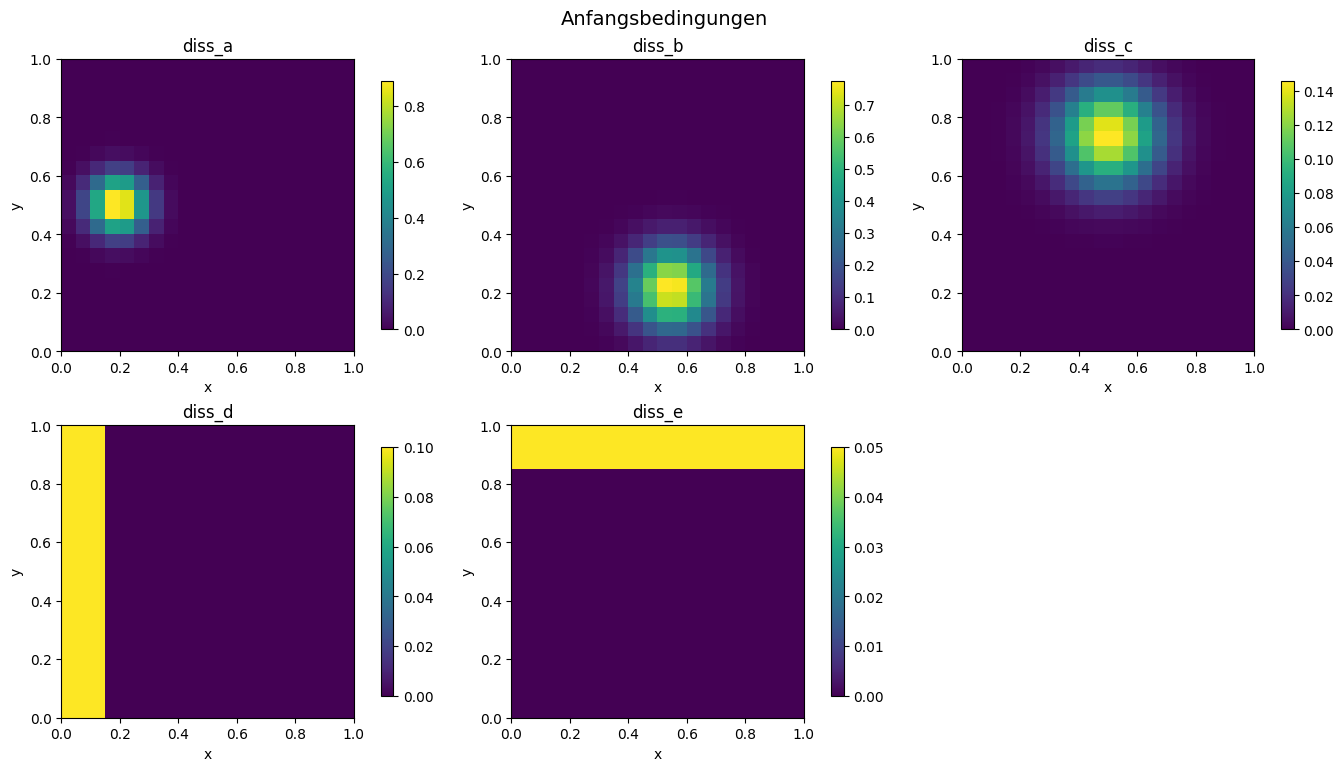

In [ ]:
initial_fields = make_initial_conditions(library.n_species, X, Y)
plot_species(initial_fields, 'Initial Conditions')
plt.show()


In [ ]:
fields = initial_fields.copy()
mass_history = []

for step in range(n_steps):
    before_transport = fields.copy()
    transported = transport_step(fields, diffusivities, dt, dx, dy, vx, vy)
    fields = reaction_step(before_transport, transported)
    mass_history.append(fields.sum(axis=(1, 2)))

mass_history = np.asarray(mass_history)
final_fields = fields
print(f'Simulation complete: t = {n_steps * dt:.2f}')


KeyboardInterrupt: 

In [ ]:
plot_species(final_fields, 'State after Operator Splitting')
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
time = dt * np.arange(1, n_steps + 1)

for idx in range(library.n_species):
    label = library.species_names[idx] if idx < len(library.species_names) else f'species_{idx+1}'
    axes[0].plot(time, mass_history[:, idx], label=label)

axes[0].set_title('Total mass per species')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Sum over all cells')
axes[0].legend(loc='best', fontsize=8)

species_to_show = 0
im = axes[1].imshow(final_fields[species_to_show] - initial_fields[species_to_show], origin='lower', extent=[0, lx, 0, ly], cmap='coolwarm')
label = library.species_names[species_to_show] if library.species_names else 'species_1'
axes[1].set_title(f'Change for {label}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(im, ax=axes[1], shrink=0.85)
plt.show()
